# Building an epigenetic methylation clock with scikit-learn

Reference articles:
- Horvath, Genome Biology 2013: https://genomebiology.biomedcentral.com/articles/10.1186/gb-2013-14-10-r115#MOESM21
- Varshavsky et al. Cell Reports Methods 2023: https://www.cell.com/cell-reports-methods/fulltext/S2667-2375(23)00211-4

# Data loading & inspection

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

folder = 'data/'
datasets = [ x for x in os.listdir(folder) if x.endswith('.csv') and x.startswith('GSE')]

tables = []

for dataset in datasets:
    name = dataset.split('.')[0]
    table = pd.read_csv(os.path.join(folder,dataset),index_col=0).transpose()
    table['Source'] = name
    print(dataset,table.shape)
    tables.append(table)

full_table = pd.concat(tables,axis=0,join='outer')


methylation_site_names = [x for x in full_table.columns if x not in ['age','Source']]

if os.path.exists(os.path.join(folder, 'site_annotations.csv')):    
    methylation_site_annotations = pd.read_csv(os.path.join(folder, 'site_annotations.csv'),index_col=0)    
else:
    methylation_site_annotations = pd.read_csv('humanmethylation450_15017482_v1-2.csv',skiprows=7,index_col='IlmnID')
    methylation_site_annotations = methylation_site_annotations.loc[methylation_site_names][['CHR','MAPINFO','Strand','SourceSeq','UCSC_RefGene_Name']]
    methylation_site_annotations.to_csv(os.path.join(folder, 'site_annotations.csv'))

GSE72680.csv (422, 1048)
GSE157131.csv (1218, 2280)
GSE55763.csv (2639, 2376)
GSE154566.csv (235, 936)
GSE69270.csv (184, 981)
GSE147221.csv (679, 2376)
GSE73103.csv (355, 979)
GSE64495.csv (113, 2376)
GSE40279.csv (656, 2376)
GSE42861.csv (689, 2376)
GSE87648.csv (382, 2351)
GSE36054.csv (134, 2376)
GSE41169.csv (95, 2376)
GSE72775.csv (335, 2376)
GSE51032.csv (845, 2376)
GSE105018.csv (1658, 1026)
GSE103657.csv (586, 995)
GSE84727.csv (665, 1027)
GSE30870.csv (20, 2376)


## Inspecting the dataset

Pay attention that for some individuals, not all methylation levels were measured.

In [2]:
full_table.head()

,age,cg00058879,cg00059225,cg00080081,cg00094518,cg00101260,cg00103778,cg00129827,cg00144180,cg00145253,...,ch.5.432310R,ch.5.79606571R,ch.6.2925136R,ch.6.41978480R,ch.7.135065R,ch.7.2635062R,ch.7.2986028F,ch.7.3189261R,ch.8.103893680R,ch.9.1059422R
GSM1868353,70.0,0.252,0.521,0.065,0.211,0.205,0.246,0.108,0.944,0.310,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM1868174,22.0,0.215,0.417,0.155,0.069,0.245,0.385,0.243,0.797,0.210,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM1868180,21.0,0.046,0.326,0.183,0.022,0.319,0.267,0.211,0.833,0.210,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM1868183,43.0,0.137,0.433,0.103,0.092,0.291,0.331,0.208,0.901,0.285,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM1946528,44.0,0.160,0.463,0.130,0.118,0.279,0.267,0.207,0.830,0.280,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Inspecting the metadata for each methylation site.
- IlmnID: Name.
- CHR: Chromosome.
- MAPINFO: start position along the reference genome.
- STRAND: on which strand is the CpG site located.
- Source: The corresponding DNA fragment

In [3]:
methylation_site_annotations.head()

,CHR,MAPINFO,Strand,SourceSeq,UCSC_RefGene_Name
IlmnID,,,,,
cg00058879,22.0,40082173.0,F,GGGCGGCCAGGCTGCTGGTGCTGCTGAACTTCCTGGCGGGCGTGAG...,CACNA1I;CACNA1I
cg00059225,5.0,151304357.0,F,GCAGGGAGCCAACAGACACGCTGGAGTTTAACAAACAGCAATACTC...,GLRA1;GLRA1;GLRA1;GLRA1
cg00080081,17.0,33701776.0,F,CGCACGTTTGTTAAAATGAGGTCATAATGTTCATGCTGTTTCATAA...,SLFN11;SLFN11;SLFN11;SLFN11;SLFN11
cg00094518,7.0,130418549.0,F,TCTGGGCGGACTTGCGCGGCAGCTCTGGCGAGGGCTCCTGGGAGAA...,KLF14
cg00101260,17.0,53426657.0,R,CGGTTCCAATGAAGCGTGGAGCATCTGTGATTCCAATCCTGAGGGG...,NaN


# Part I: Exploratory Data Analysis

1.	For each CpG site, calculate the Spearman correlation coefficient between its methylation level and the age of the donor. Display the result as a histogram and comment on the findings.

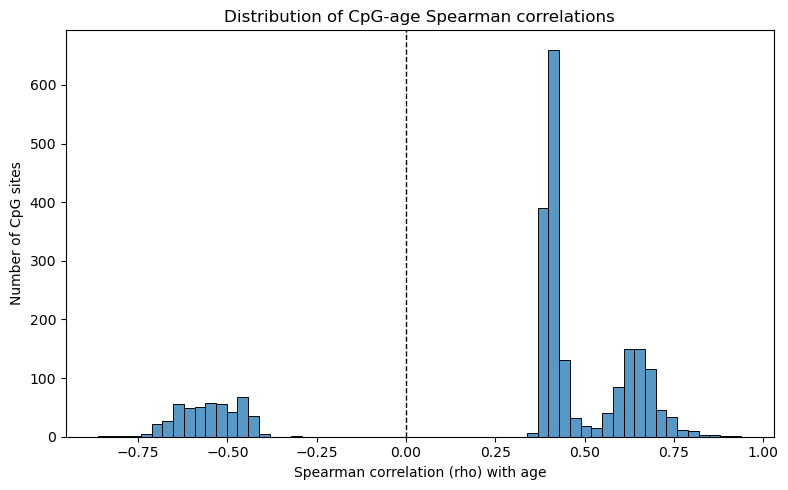

count    2374.000000
mean        0.285065
std         0.434105
min        -0.862045
25%         0.385047
50%         0.410338
75%         0.584071
max         0.939139
dtype: float64

Top positive correlations:
cg16867657    0.939139
cg22454769    0.900077
cg06639320    0.879080
cg21572722    0.853108
cg04875128    0.849220
dtype: float64

Top negative correlations:
cg19283806   -0.862045
cg26685941   -0.809738
cg08128734   -0.777279
cg05412028   -0.745590
cg00573770   -0.735663
dtype: float64
Number of CpG sites with significant positive correlation with age: 1899
Number of CpG sites with significant negative correlation with age: 475
Number of CpG sites with moderate positive correlation with age: 1231


In [4]:
# Q1: Spearman correlation of each CpG site with age
age = full_table["age"]
methylation_sites = full_table[methylation_site_names]

# One rho value per CpG site
spearman_rho = methylation_sites.apply(lambda col: col.corr(age, method="spearman"))

# Histogram
plt.figure(figsize=(8, 5))
sns.histplot(spearman_rho.dropna(), bins=60)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Spearman correlation (rho) with age")
plt.ylabel("Number of CpG sites")
plt.title("Distribution of CpG-age Spearman correlations")
plt.tight_layout()
plt.show()

# Quick numeric summary
print(spearman_rho.describe())
print("\nTop positive correlations:")
print(spearman_rho.nlargest(5))
print("\nTop negative correlations:")
print(spearman_rho.nsmallest(5))


# Count how many CpG sites have significant positive or negative correlation with age
significant_positive = (spearman_rho > 0.25).sum()  #
significant_negative = (spearman_rho < -0.25).sum()  #
print(f"Number of CpG sites with significant positive correlation with age: {significant_positive}")
print(f"Number of CpG sites with significant negative correlation with age: {significant_negative}")

moderately_positive = ((0.5 > spearman_rho) & (spearman_rho > 0.25)).sum() 
print(f"Number of CpG sites with moderate positive correlation with age: {moderately_positive}")

Since the dataset contains a subset of the 450K sites that showed correlation to age, we expect to see only segnificant correlation. It seems that perhaps the sites that showed correlation lower than 0.25 were removed.

It seems that there are much more positively-correlated sites tham negatively-correlated, so we summed to get the count for each group. We got that only about a quarter of the sites are negatively-correlated, and the rest are positively correlated. We see the peak between 0.25 and 0.5 with half of the samples.

2.	For the 5 CpG sites with highest and lowest Spearman correlation coefficient values, visualize the relationship between methylation level and age using a scatter plot. Comment on the findings.

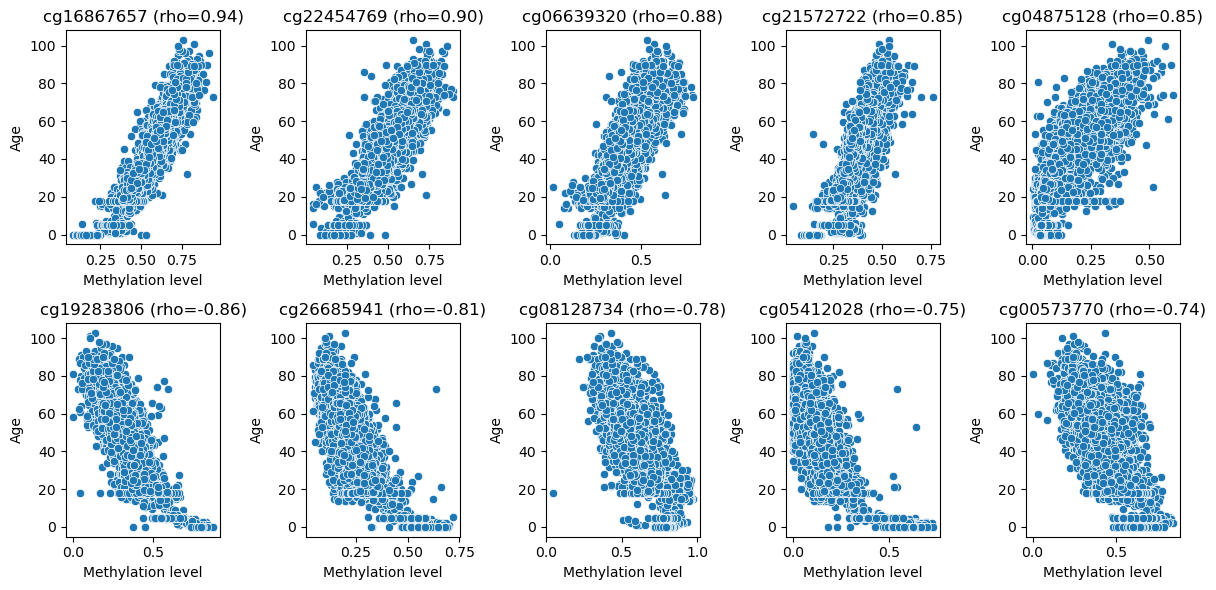

In [5]:
# Q2: Plot top 5 positively and negatively correlated CpG sites
top_positive_sites = spearman_rho.nlargest(5).index
top_negative_sites = spearman_rho.nsmallest(5).index
plt.figure(figsize=(12, 6))
for i, site in enumerate(top_positive_sites):
    plt.subplot(2, 5, i + 1)
    sns.scatterplot(x=full_table[site], y=age)
    plt.title(f"{site} (rho={spearman_rho[site]:.2f})")
    plt.xlabel("Methylation level")
    plt.ylabel("Age")
for i, site in enumerate(top_negative_sites):
    plt.subplot(2, 5, i + 6)
    sns.scatterplot(x=full_table[site], y=age)
    plt.title(f"{site} (rho={spearman_rho[site]:.2f})")
    plt.xlabel("Methylation level")
    plt.ylabel("Age")
plt.tight_layout()
plt.show()

As expected the 5 most-positively and negatively correlated sites exhibit clear trend when visuallising age over methylation level.

3.	Select all sites located along Chromosome 10 and reorder them by their location along the genome. Calculate the matrix of Spearman correlation coefficients between all pairs of methylation levels and visualize as a heatmap. Comment on the findings.

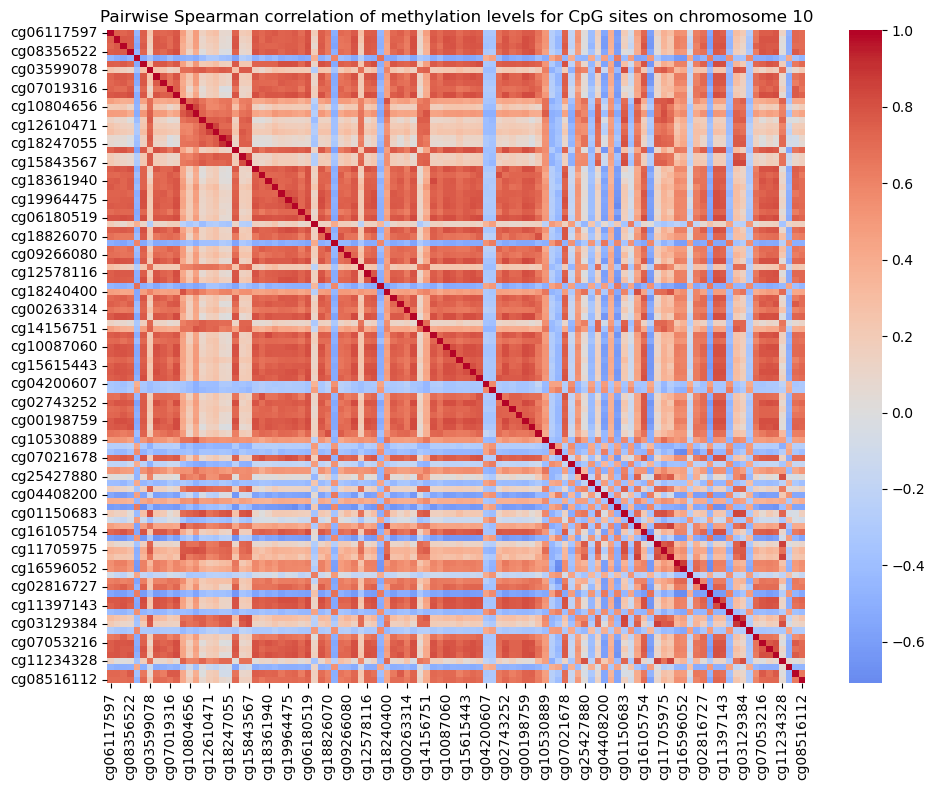

In [6]:
# Q3: Get all sites on chromosome 10 by order of position, and plot a heatmap of the pairwise Spearman correlation
# for the methylation levels of these sites across samples.
chr10_sites = methylation_site_annotations[methylation_site_annotations['CHR'] == 10].sort_values('MAPINFO').index
chr10_methylation = full_table[chr10_sites]
chr10_spearman = chr10_methylation.corr(method='spearman')
plt.figure(figsize=(10, 8))
# labels should be "site name (position)"
sns.heatmap(chr10_spearman, cmap='coolwarm', center=0)
plt.title("Pairwise Spearman correlation of methylation levels for CpG sites on chromosome 10")
plt.tight_layout()
plt.show()

It appears that there are multiple areas of high correlation between sites cg10530889 and cg18361940 (shows a relatively dark-red square), that hints there might be a spatial effect between the consecutive positions between them.

The range at the end of the chromosome seems more distorted, meanning the positions there have different pattenrs of correlation, suggestiong they dont have a strong spatial dependence.

we can also look at positions such as cg04200607 that show low correlation with other positions sampled along the entire chromosome.

# Part II: Data Partition

Here, we perform the data partition, splitting the dataset into a training and a test set. We then split the training set into five folds for cross-validation purpose.

- The dataset was compiled from 19 separate studies. To account for potential "batch effects" (i.e., distribution shift from one study to the other), we use one of the study as test set.

- For the cross-validation, we use a stratified K-fold approach.

In [4]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import KBinsDiscretizer
X , Y = full_table[methylation_site_names], full_table['age']
study = full_table['Source'] # The study chosen from.

test_set = (study == 'GSE84727')

X_train, Y_train = X[~test_set], Y[~test_set]
X_test, Y_test = X[test_set], Y[test_set]


Y_train_binned = KBinsDiscretizer(n_bins=20,encode='ordinal').fit_transform(Y_train.to_numpy()[:,None])[:,0]
skf = StratifiedKFold(n_splits=5,random_state=0,shuffle=True)
skf.get_n_splits(X_train,Y_train_binned)

/opt/miniconda3/envs/bioenv/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/opt/miniconda3/envs/bioenv/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


5

4.	Report the number of samples per study and visualize the age distribution for each of the 19 studies, using a boxplot. Comment on the findings.

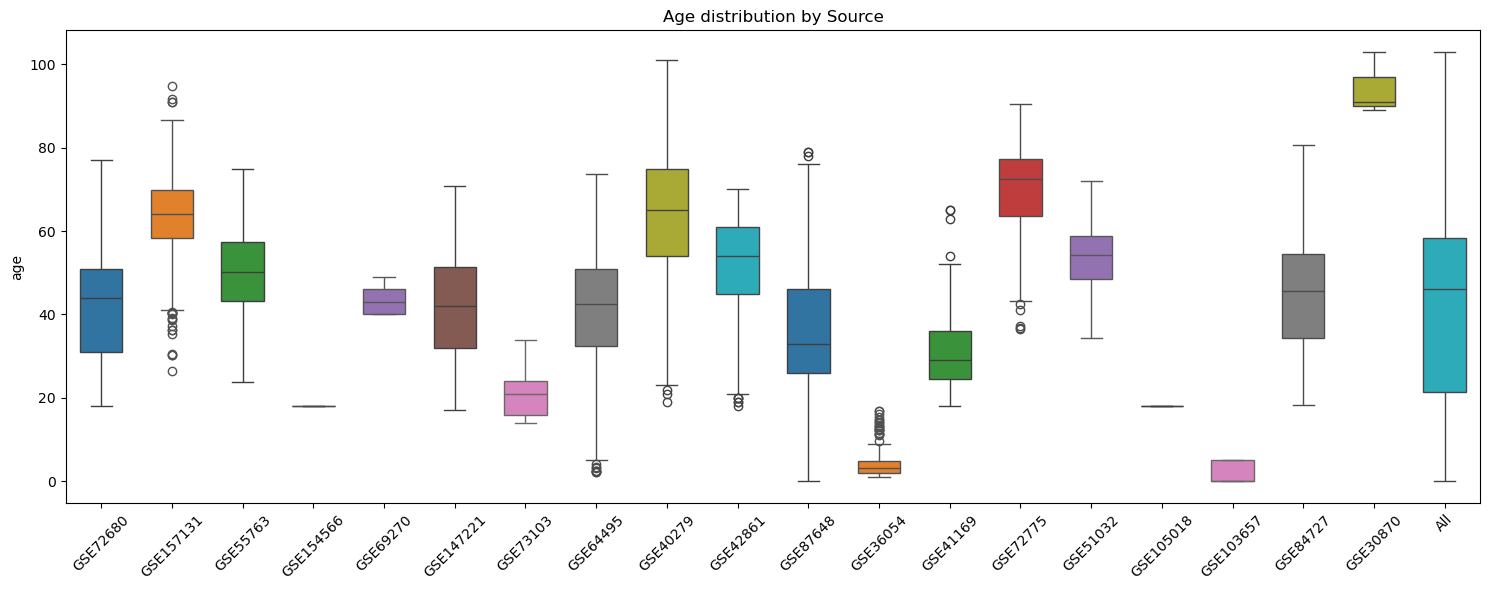

Number of GSE72680 samples: 422
Number of GSE157131 samples: 1218
Number of GSE55763 samples: 2639
Number of GSE154566 samples: 235
Number of GSE69270 samples: 184
Number of GSE147221 samples: 679
Number of GSE73103 samples: 355
Number of GSE64495 samples: 113
Number of GSE40279 samples: 656
Number of GSE42861 samples: 689
Number of GSE87648 samples: 382
Number of GSE36054 samples: 134
Number of GSE41169 samples: 95
Number of GSE72775 samples: 335
Number of GSE51032 samples: 845
Number of GSE105018 samples: 1658
Number of GSE103657 samples: 586
Number of GSE84727 samples: 665
Number of GSE30870 samples: 20


In [8]:
plt.figure(figsize=(15, 6))

positions = []
labels = []

for j, t in enumerate(tables):
    source = t.iloc[0]["Source"]

    sns.boxplot(
        y=t["age"],
        positions=[j],
        width=0.6
    )

    positions.append(j)
    labels.append(source)

# add one boxplot for all the data
sns.boxplot(
    y=full_table["age"],
    positions=[len(tables)],
    width=0.6
)
positions.append(len(tables))
labels.append("All")

plt.xlim(-0.5, len(tables) + 1 - 0.5)
plt.xticks(positions, labels, rotation=45)
plt.title("Age distribution by Source")
plt.tight_layout()
plt.show()

for j, t in enumerate(tables):
    source = t.iloc[0]["Source"]
    print(f"Number of {source} samples: {len(t)}")

4. We can see that some of the datasets have a very different distribution than the rest. like GSE103657 that consist of samples of infants, or GSE30870 that consist only of 90-100 year old patients. GSE69270 may have the same median as the avarage median across the datasets, but it has a very small variance.

5.	Read how the partition between train and test was done on the notebook.
a.	Why did we use dataset “GSE84727” as a test set rather than by using a random split?
b.	Why did we use a stratified split for the training set rather than a random split or a grouped split?

5a. We added a boxplot that shows age distribution for the entire data. We see that for the selected test dataset, the median is vert simmilar to the median of the entire data. It is clearly visible that there are dataset that do not represent the distribution of the entire data either by range, median or both - for example GSE103657. Sampleing them as the test set may result in poor prediction.

5b. It is a good practice to try and train the model based on expected real-world age distribution. using stratified k folds helps maintaining the same age distribution across all the folds.

# Part III: Training and evaluating a linear model

Build a scikit-learn Pipeline consisting of:
-	An imputer for missing values (SimpleImputer)
-	Top-K feature selection using the F-statistics of the correlation coefficient (functions: SelectKBest and f_regression).
-	Ridge Regression.
For each of the following values of K: [5,10,20,30,50,100,500,1000], select the optimal L2 regularization strength over the range by cross-validation.

6.	Report the performance of the model on the test set as a table with error bars (defined as the standard deviation of the absolute error, divided by the square root of the test set size).
How does the performance evolve with K?

In [24]:
# Create an sklearn pipline that:
#  - Imputes missing values with SimpleImputer
#  - Selects top-k features by correlation with age (SelectKBest and f_regression) via cross-validation on the training set
from wheel.vendored.packaging.specifiers import Specifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

k_values = [5,10,20,30,50,100,500,1000]

cv_splits = list(skf.split(X_train, Y_train_binned))


best_models = []
for k in k_values:
    pipeline = Pipeline([
        ('imputer', SimpleImputer()),
        ('feature_selection', SelectKBest(score_func=f_regression, k=k)),
        ("regressor", Ridge())
    ])

    param_grid = {'regressor__alpha': np.logspace(-4, 2, 10)}
    grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv_splits,
    scoring="neg_mean_absolute_error"
)
    grid_search.fit(X_train, Y_train)

    best_model = grid_search.best_estimator_
    best_performance = -grid_search.best_score_
    print(f"Best MAE for k={k}: {best_performance:.4f} with alpha={grid_search.best_params_['regressor__alpha']}")
    best_models.append(best_model)

# Report performance of the model on the test set in a table with error bars: std of abs error / sqrt(n_test_samples).
report = []
for k, model in zip(k_values, best_models):
    predictions = model.predict(X_test)
    mae = np.mean(np.abs(predictions - Y_test))
    std_error = np.std(np.abs(predictions - Y_test)) / np.sqrt(len(Y_test))
    report.append((k, mae, std_error))
ridge_report_df = pd.DataFrame(report, columns=['k', 'MAE', 'Std_Error'])
print(ridge_report_df)

Best MAE for k=5: 4.7600 with alpha=0.0001
Best MAE for k=10: 4.3291 with alpha=0.21544346900318823
Best MAE for k=20: 4.1150 with alpha=0.046415888336127774
Best MAE for k=30: 3.9732 with alpha=0.0001
Best MAE for k=50: 3.7517 with alpha=0.0001
Best MAE for k=100: 3.3251 with alpha=0.21544346900318823
Best MAE for k=500: 2.5233 with alpha=1.0
Best MAE for k=1000: 2.3251 with alpha=4.641588833612772
      k       MAE  Std_Error
0     5  4.562911   0.144014
1    10  4.358229   0.135286
2    20  4.323991   0.133171
3    30  3.938663   0.125587
4    50  3.584626   0.118703
5   100  2.878721   0.094124
6   500  2.305741   0.078524
7  1000  2.153986   0.076012


The performence slightly improves along growing K, both in MAE and error bars. Allowing small groups of features the models can't grasp the required complexity expressed in the feartures to fit well. That is probably why it improves as we incease k, howerver there is a point where the improvment in performence flattens. We can see that the L2 regulation limits from choosing more features for greater values of K, which may explain why at this point the MAE decreasement is insignificant.

7.	For K=50, plot the feature importance of the selected sites.
Are some chromosomes over-represented among these sites?

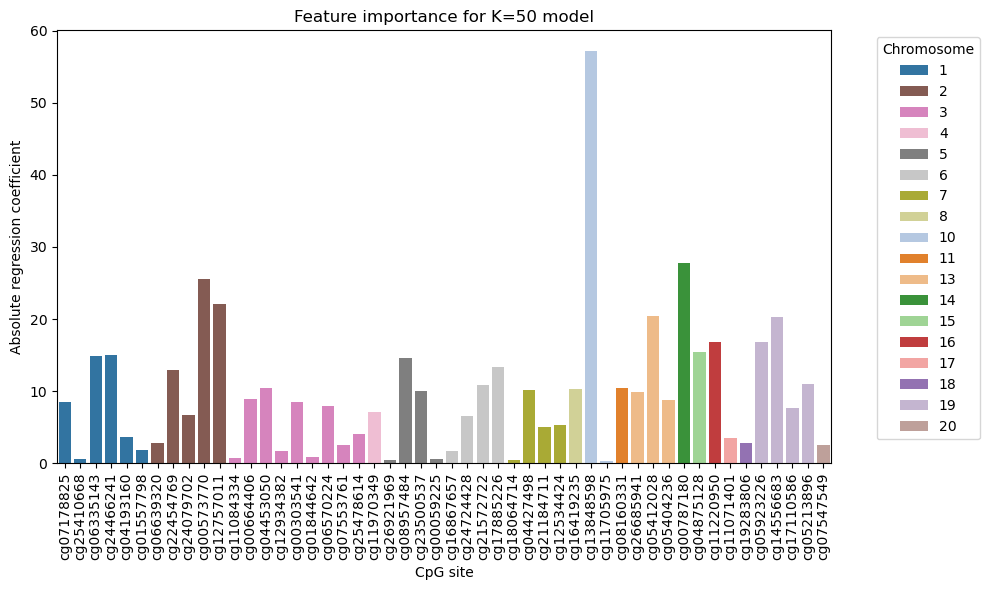

In [10]:
# Plot feature importance for K=50 model, from the regression coefficients of the Ridge model,
# sort features by genome position and color labels by chromosome
# use methylation_site_annotations to get the chromosome and position of each feature.
k_features_pool = best_models[4].named_steps['feature_selection'].get_support(indices=True)
selected_features = X_train.columns[k_features_pool]
selected_annotations = methylation_site_annotations.loc[selected_features]
selected_annotations = selected_annotations.sort_values(['CHR', 'MAPINFO'])

# For non gradient coloring
selected_annotations['CHR'] = selected_annotations['CHR'].astype(int).astype(str)
plt.figure(figsize=(10, 6))

unique_chrs = sorted(selected_annotations['CHR'].unique())

palette = dict(zip(
    unique_chrs,
    sns.color_palette("tab20", n_colors=len(unique_chrs))
))


sns.barplot(x=selected_annotations.index, y=np.abs(best_models[4].named_steps['regressor'].coef_),
hue=selected_annotations['CHR'], dodge=False, palette=palette)
plt.xticks(rotation=90)
plt.xlabel("CpG site")
plt.ylabel("Absolute regression coefficient")
plt.title("Feature importance for K=50 model")
plt.legend(title="Chromosome", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Some chromosomes are more represented then others. chromosomes 9 and 12 arn't even chosen, and 17,18,20 for instance have single locus present with a very low importance. Chromosome 10 has 2 sites one of wich is the most important feature (twice in size from the next-important). Chromosome 3 has the most sites but with a relatively low significance, may be interesting to check their respective correlation.

8.	For each of the five folds, the selected sites may be different. How many sites are found in all five folds? In at least 2 folds? Discuss the findings.

In [11]:
# Q8: Count for each features in how many folds it was selected by SelectKBest, and create a df
feature_counts = pd.DataFrame(0, index=X_train.columns, columns=range(5))
for fold, (train_idx, val_idx) in enumerate(cv_splits):
    X_fold_train, Y_fold_train = X_train.iloc[train_idx], Y_train_binned[train_idx]
    # Impute missing values in the training fold
    X_fold_train = SimpleImputer(strategy='mean').fit_transform(X_fold_train)
    selector = SelectKBest(score_func=f_regression, k=50)
    selector.fit(X_fold_train, Y_fold_train)
    selected_indices = selector.get_support(indices=True)
    feature_counts.iloc[selected_indices, fold] = 1
feature_counts['Total_Selected'] = feature_counts.sum(axis=1)

# show features that were selected in all 5 folds
consistently_selected = feature_counts[feature_counts['Total_Selected'] == 5]
print("No. Features selected in all 5 folds:", len(consistently_selected))


# show features that were selected in at least 2 folds
selected_at_least_2 = feature_counts[feature_counts['Total_Selected'] >= 2]
print("No. Features selected in at least 2 folds:", len(selected_at_least_2))

No. Features selected in all 5 folds: 48
No. Features selected in at least 2 folds: 53


96% percent of the features selected by pearson correlation were chosen in all five folds. it suggests that their signal is high and stable across different subsets of the data.

# Part IV: Automated feature selection by LASSO
Replace the previous Pipeline by a Pipeline consisting of:
-	An imputer for missing values (SimpleImputer)
-	LASSO Regression.

9.	For various values of the L1 regularization strength, fit a model (on the full training set) and calculate the performance on the test set as well as the number of CpG sites with non-zero coefficients. Plot the test set performance as function of the number of sites for both models.

Why would feature selection with LASSO outperform feature selection by Pearson correlation? Conversely, why would Ridge outperform LASSO? Suggest a “best-of-both worlds” solution.

In [8]:
from sklearn.linear_model import Lasso

# 1. Define a range of alphas to sweep through
alphas = np.logspace(-2, 0, 10) 

lasso_results = []
for a in alphas:
    lasso_pipeline = Pipeline([
        ('imputer', SimpleImputer()),
        ('regressor', Lasso(alpha=a, max_iter=3000, tol=1e-3))
    ])

    lasso_pipeline.fit(X_train, Y_train)

    # Predict and calculate MAE
    predictions = lasso_pipeline.predict(X_test)
    mae = np.mean(np.abs(predictions - Y_test))

    # Count non-zero coefficients (the "selected" features)
    # The regressor is the second step in the pipeline
    coefs = lasso_pipeline.named_steps['regressor'].coef_
    num_sites = np.sum(coefs != 0)

    lasso_results.append((a, num_sites, mae))

# 2. Convert to DataFrame for plotting
lasso_df = pd.DataFrame(lasso_results, columns=['alpha', 'num_features', 'MAE'])
lasso_df

,alpha,num_features,MAE
0,0.010000,122,2.928827
1,0.016681,79,2.954040
2,0.027826,53,2.889206
3,0.046416,35,2.886917
4,0.077426,23,2.977100
5,0.129155,18,3.131718
6,0.215443,11,3.362664
7,0.359381,7,3.827982
8,0.599484,6,4.562440
9,1.000000,5,6.040016


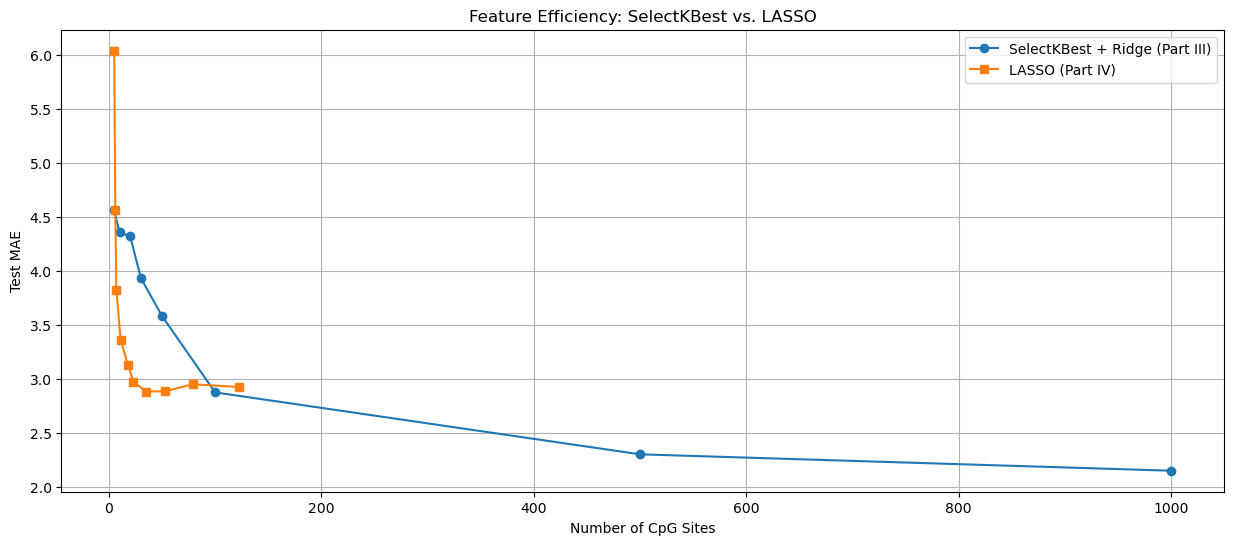

In [26]:
plt.figure(figsize=(15, 6))
plt.plot(ridge_report_df['k'], ridge_report_df['MAE'], marker='o', label='SelectKBest + Ridge (Part III)')
plt.plot(lasso_df['num_features'], lasso_df['MAE'], marker='s', label='LASSO (Part IV)')
plt.xlabel('Number of CpG Sites')
plt.ylabel('Test MAE')
plt.title('Feature Efficiency: SelectKBest vs. LASSO')
plt.legend()
plt.grid(True)
plt.show()

feature selection by pearson correlation treats features individually, so it can choose a group of features that are highly corelative to the target but redundent. lasso considers all sites simultanously while choosing features, so if two features gives the same information, choosing both won't improve the error as much as it would increase the l1 penalty.

By choosing only one 'representetive' feature out of a group of redudant features, lasso is more prone to be affected by noise of this specific feature. ridge is more immune to this problem because it would assign waights to all the redudant features and the sum of them will cover on the noise.

a solution to this problem would be to use an objective that has both l1 and l2 regularization terms, so that it would balance sparsity and stability. 

10.	Repeat the analysis of Q8 with alpha=0.025. Are the findings different? Propose an 
explanation.

In [24]:
feature_counts = pd.DataFrame(0, index=X_train.columns, columns=range(5))
lasso_pipeline.set_params(regressor__alpha=0.025)
for fold, (train_idx, val_idx) in enumerate(cv_splits):
    X_fold_train, Y_fold_train = X_train.iloc[train_idx], Y_train_binned[train_idx]
    lasso_pipeline.fit(X_fold_train, Y_fold_train)
    coefs = lasso_pipeline.named_steps['regressor'].coef_
    selected_indices = np.where(coefs != 0)[0]
    print(f"Fold {fold}: selected {len(selected_indices)} features")
    feature_counts.iloc[selected_indices, fold] = 1
feature_counts['Total_Selected'] = feature_counts.sum(axis=1)

# show features that were selected in all 5 folds
consistently_selected = feature_counts[feature_counts['Total_Selected'] == 5]
print("\nNo. Features selected in all 5 folds:", len(consistently_selected))


# show features that were selected in at least 2 folds
selected_at_least_2 = feature_counts[feature_counts['Total_Selected'] >= 2]
print("No. Features selected in at least 2 folds:", len(selected_at_least_2))

Fold 0: selected 26 features
Fold 1: selected 27 features
Fold 2: selected 25 features
Fold 3: selected 25 features
Fold 4: selected 26 features

No. Features selected in all 5 folds: 24
No. Features selected in at least 2 folds: 26


Although we said that LASSO is less stable, meaning it chooses one random feature from each group of redundent features, therefore leading to incosistency between folds, in this experiment we didn't get this result - like in Q8, chosen features were consistent.
This might mean that there are many independent, non-redundant informative features so that LASSO didn't need to use redudant features, or that in groups of redudant features, one of them is more informative than others so it gets chosen as a representative in all folds.

# Part V: Experimenting with the loss function.

Since our target metric is the MAE rather than the mean square error, we might get better results by using it as a training loss function. This is implemented in two scikit-learn classes:
(1)	QuantileRegression (with quantile=0.5) and L1 regularization. Exact, but slow optimization by linear programming.
(2)	SGDRegression (with loss=’huber’,epsilon=1e-2) and L1/L2 regularization. Faster, approximate optimization by stochastic gradient descent. Pay attention that the learning rate needs to be adjusted.

11.	Repeat question 6. with the MAE loss rather than Ridge regression and compare the findings.

In [26]:
from sklearn.linear_model import QuantileRegressor

k_values = [5,10,20,30,50,100,500,1000]
cv_splits = list(skf.split(X_train, Y_train_binned))

best_models = []
for k in k_values:
    pipeline = Pipeline([
        ('imputer', SimpleImputer()),
        ('feature_selection', SelectKBest(score_func=f_regression, k=k)),
        ("regressor", QuantileRegressor())
    ])

    param_grid = {'regressor__alpha': np.logspace(-4, 2, 10)}
    grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv_splits,
    scoring="neg_mean_absolute_error"
)
    grid_search.fit(X_train, Y_train)

    best_model = grid_search.best_estimator_
    best_performance = -grid_search.best_score_
    print(f"Best MAE for k={k}: {best_performance:.4f} with alpha={grid_search.best_params_['regressor__alpha']}")
    best_models.append(best_model)

# Report performance of the model on the test set in a table with error bars: std of abs error / sqrt(n_test_samples).
report = []
for k, model in zip(k_values, best_models):
    predictions = model.predict(X_test)
    mae = np.mean(np.abs(predictions - Y_test))
    std_error = np.std(np.abs(predictions - Y_test)) / np.sqrt(len(Y_test))
    report.append((k, mae, std_error))
report_df = pd.DataFrame(report, columns=['k', 'MAE', 'Std_Error'])
print(report_df)

Best MAE for k=5: 4.6862 with alpha=0.0001
Best MAE for k=10: 4.3069 with alpha=0.0001
Best MAE for k=20: 4.1018 with alpha=0.0001
Best MAE for k=30: 3.9621 with alpha=0.0001
Best MAE for k=50: 3.7362 with alpha=0.0001
Best MAE for k=100: 3.3111 with alpha=0.0001
Best MAE for k=500: 2.5088 with alpha=0.0001
Best MAE for k=1000: 2.3123 with alpha=0.0001
      k       MAE  Std_Error
0     5  4.908305   0.149062
1    10  4.558903   0.137792
2    20  4.541443   0.136515
3    30  4.042245   0.128019
4    50  3.663394   0.121177
5   100  2.943096   0.097038
6   500  2.298936   0.078415
7  1000  2.173499   0.077106


this version is very slow, and also all k got the same minimal alpha, suggesting the search interval should be larger.

In [ ]:
from sklearn.linear_model import QuantileRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

k_values = [5,10,20,30,50,100,500,1000]
cv_splits = list(skf.split(X_train, Y_train_binned))
report = []

for k in k_values:
    pipeline = Pipeline([
        ('imputer', SimpleImputer()),
        ('scaler', StandardScaler()),
        ('feature_selection', SelectKBest(score_func=f_regression, k=k)),
        ('regressor', SGDRegressor(loss='huber', epsilon=1e-2, learning_rate='adaptive'))])

    param_grid = {'regressor__alpha': np.logspace(-10, -4, 10)}
    grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv_splits,
    scoring="neg_mean_absolute_error"
    )
    grid_search.fit(X_train, Y_train)

    best_model = grid_search.best_estimator_
    best_performance = -grid_search.best_score_
    print(f"Best training MAE for k={k}: {best_performance:.4f} with alpha={grid_search.best_params_['regressor__alpha']}")

    predictions = best_model.predict(X_test)
    mae = np.mean(np.abs(predictions - Y_test))
    std_error = np.std(np.abs(predictions - Y_test)) / np.sqrt(len(Y_test))
    report.append((k, mae, std_error))
    
sgd_report_df = pd.DataFrame(report, columns=['k', 'MAE', 'Std_Error'])
print(sgd_report_df)

Best training MAE for k=5: 5.0105 with alpha=2.1544346900318823e-05
Best training MAE for k=10: 4.6139 with alpha=2.1544346900318866e-09
Best training MAE for k=20: 4.4848 with alpha=2.1544346900318866e-09
Best training MAE for k=30: 4.4213 with alpha=1e-08
Best training MAE for k=50: 4.2741 with alpha=4.6415888336127727e-10
Best training MAE for k=100: 3.6917 with alpha=1e-10
Best training MAE for k=500: 2.5711 with alpha=4.641588833612773e-08
Best training MAE for k=1000: 2.3317 with alpha=2.1544346900318866e-09
      k       MAE  Std_Error
0     5  6.621013   0.172969
1    10  5.722464   0.158751
2    20  5.419814   0.156014
3    30  5.317501   0.153089
4    50  5.197137   0.151692
5   100  3.767944   0.119511
6   500  2.454446   0.084302
7  1000  2.343948   0.082642


There is only a small improvement in performance.
it suggests that the dataset is relatively clean of outliers, as the MSE and MAE are close.

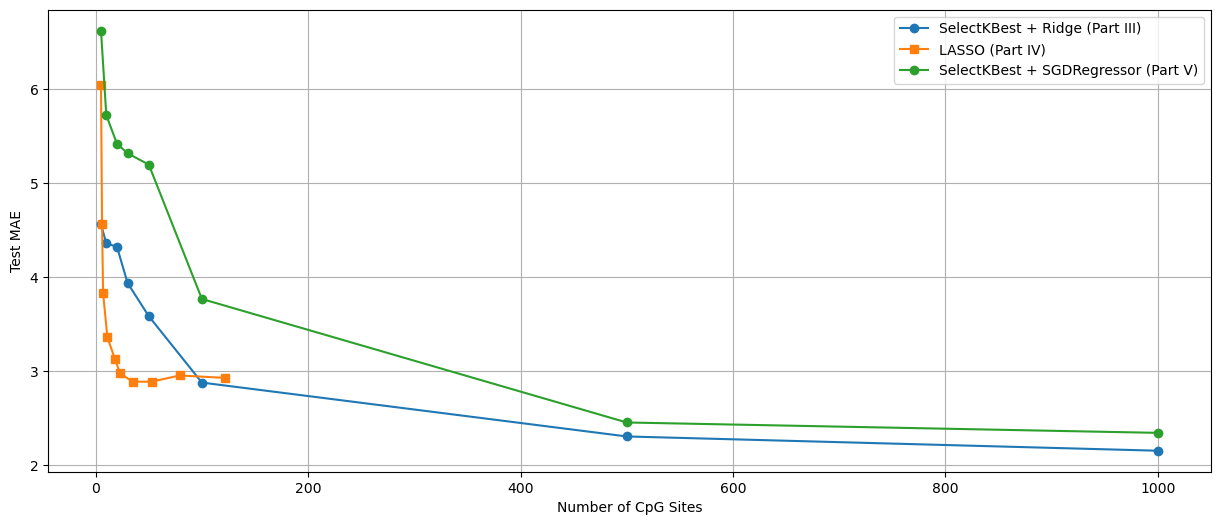

In [16]:
plt.figure(figsize=(15, 6))
plt.plot(ridge_report_df['k'], ridge_report_df['MAE'], marker='o', label='SelectKBest + Ridge (Part III)')
plt.plot(lasso_df['num_features'], lasso_df['MAE'], marker='s', label='LASSO (Part IV)')
plt.plot(sgd_report_df['k'], sgd_report_df['MAE'], marker='o', label='SelectKBest + SGDRegressor (Part V)')
plt.xlabel('Number of CpG Sites')
plt.ylabel('Test MAE')
plt.legend()
plt.grid(True)
plt.show()

# Part VI: Training a Generalized Additive Model (GAM)

The exploratory data analysis showed a non-linear relationship between methylation level and age, suggesting that a GAM model may be more appropriate. To this end, build a Pipeline consisting of the following steps:
-	An imputer for missing values (SimpleImputer)
-	Top-K feature selection using the F-statistics of the correlation coefficient (functions: SelectKBest and f_regression).
-	SplineTransformer using cubic splines, uniformly spaced knots, linear extrapolation.
-	Ridge regression.

12.	For each of the following values of K: [5,10,20,30,50], select the optimal regularization strength and number of knots, and report the performance over the test set. Compare the results with the ones of Part III.

13.	Plot the feature effect functions using the Partial Dependency plot function of scikit-learn. Conclude on the benefits of using trainable non-linearities.

14.	Do you expect that performance could be improved by instead implementing the GAM with boosted trees of depth 1?

# Part VII: Glass-box vs Black-Box models.

15.	Similarly train and evaluate a “black-box” Random Forest regressor on the same dataset. How does the performance compare with the one of the “glass-box” models? Conclude on the merits of each method.

## Bonus
Suggest and implement another approach to further improve the performance of the age predictor.

In [15]:
import marimo as mo